# Step 10: 2D Poisson Equation

We're very close now to building the final Navier-Stokes simulation that brought us here in the first place but before that, let's take a quick look at the Navier-Stokes equations for an incompresssible fluid, where $\vec{v}$ represents the velocity field:

$$ \nabla \cdot \vec{v} = 0  $$

$$ \frac{\partial \vec{v}}{\partial t} + (\vec{v} \cdot \nabla) \vec{v} = - \frac{1}{\rho} \nabla p + \nu \nabla^2 \vec{v} $$

The first equation is a representation of mass conservation at constant density. The second equation is the conservation of momentum. Yet, we have a problem: the continuity equation for incompressible flow does not have a dominant variable and there is no obvious way to couple the velocity and the pressure. In the case of compressible flow, in contranst, mass continuity would provide an evolution equation for the density $rho$, which is couple with an equation of state relating $rho$ and $p$.

In incompressible flow, the continuity equation $\nabla \cdot \vec{v} = 0$ provides a *kinematic constraint* that requires the pressure field to evolve so that the rate of expansion $\nabla \cdot \vec{v} $ should vanish everywhere. A way out of this difficulty is to construct a pressure field that guarantees continuity is satisfied; such relation can be obtained by taking the divergence of the momentum equation. In that process, a Poisson equation for the pressure shows up!

We can obtain Poisson's equation from adding a source term to the right hand side of Laplace's equation:

$$ \frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = b $$

This leads to a different behaviour within the field where there is some finite value inside the field that affects the solution. Poisson's equation acts to "relax" the initial sources in the field.

## Discretization

In discretized formed this looks pretty much exactly the same as in Step 9:

$$ \frac{p^n_{i+1,j}  - 2p^n_{i,j} + p^n_{i-1,j}}{\Delta x^2} + \frac{p^n_{i,j+1} - 2p^n_{i,j} + p^n_{i,j-1}}{\Delta y^2} = b^n_{i,j}
$$

Rearranging the discretized equation we can get:

$$ p^n_{i,j} = \frac{\Delta y^2 (p^n_{i+1,j} + p^n_{i-1,j})+ \Delta x^2 (p^n_{i,j+1} + p^n_{i,j-1}) - b^n_{i,j} \Delta x^2 \Delta y^2}{2(\Delta x^2 + \Delta y^2 )}
$$

## Initial and Boundary Conditions

We solve this equation by assuming an initial state of p = 0 everywhere. Then we add the following boundary conditions. 

$p = 0 \ \text{at} \ x = 0 , 2 \ \text{and} \ y = 0,1 $

The source term consists of two initial spikes inside the domain, as follow:

$ b_{i,j} = 100 \ \text{at} \ i = nx / 4, j = ny / 4 $

$ b_{i,j} = -100 \ \text{at} \ i = nx * 3 / 4, j =  \frac{3}{4} ny $

$ b_{i,j} = 0 \ \text{everywhere else} $

The iterations will advance in pseudo time to relax the initial spikes. The relaxation under Posisson's equation get slower as time progresses however.

## Libraries and Variable declarations

### Lib import

In [1]:
# Adding inline command to make plots appear under comments
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook

## Function Declarations

In [ ]:
def plot2D(x,y,p):
    fig = plt.figure(figsize=(11,7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    X,Y = np.meshgrid(x,y)
    surf = ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis,
            linewidth=0, antialiased=False)
    ax.set_xlim(0,2)
    ax.set_ylim(0,1)
    ax.view_init(30,225)
    ax.set_xlabel('$x$')
    ax.set_zlabel('$p$')
    ax.set_ylabel('$y$')
    ax.text2D(0.35, 0.95, "2D Poisson's Equation", transform=ax.transAxes)
    plt.show()
    return fig

### Variable Declarations

In [3]:
grid_points_x = 50
grid_points_y = 50
nt = 100
xmin = 0
xmax = 2
ymin = 0
ymax = 1

dx = (xmax - xmin) / (grid_points_x - 1) 
dy = (ymax - ymin) / (grid_points_y - 1) 

#Initializing arrays
p  = np.zeros((grid_points_x, grid_points_y))
pd = np.zeros((grid_points_x, grid_points_y))
b  = np.zeros((grid_points_x, grid_points_y))
x = np.linspace(xmin, xmax, grid_points_x)
y = np.linspace(ymin, ymax, grid_points_y)

#Source initializing
b[int(grid_points_y / 4), int(grid_points_x / 4)]  = 100
b[int(3 * grid_points_y / 4), int(3 * grid_points_x / 4)] = -100


### Solving in 2D

In [4]:
for it in range(nt):

    pd = p.copy()

    p[1:-1,1:-1] = (((pd[1:-1, 2:] + pd[1:-1, :-2]) * dy**2 +
                    (pd[2:, 1:-1] + pd[:-2, 1:-1]) * dx**2 -
                    b[1:-1, 1:-1] * dx**2 * dy**2) / 
                    (2 * (dx**2 + dy**2)))

    p[0, :] = 0
    p[grid_points_y-1, :] = 0
    p[:, 0] = 0
    p[:, grid_points_x-1] = 0

<IPython.core.display.Javascript object>

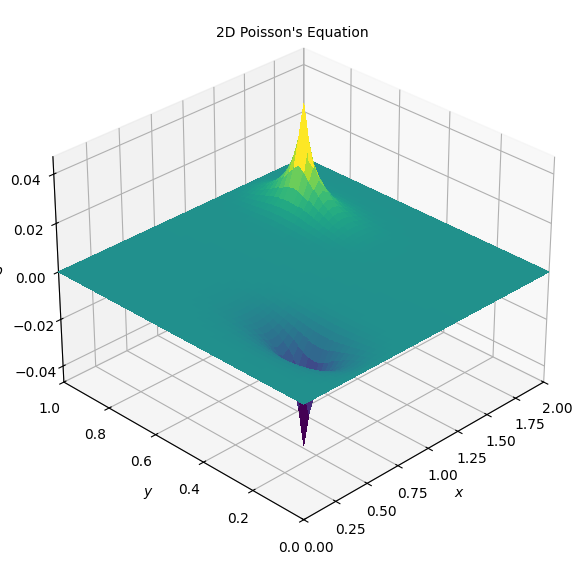

In [5]:
plot2D(x,y,p)

### Results

Clearly shows the sink and the source. Let's try to plot the behavior over time to get a better idea.

## Animating the simulation

In [6]:
#Imports for animation and display within a jupyter notebook
from matplotlib import animation, rc 
from IPython.display import HTML

#Resetting back to initial conditions
p  = np.zeros((grid_points_x, grid_points_y))
pd = np.zeros((grid_points_x, grid_points_y))
b  = np.zeros((grid_points_x, grid_points_y))

b[int(grid_points_y / 4), int(grid_points_x / 4)]  = 100
b[int(3 * grid_points_y / 4), int(3 * grid_points_x / 4)] = -100

#Generating the figure that will contain the animation
fig = plt.figure(figsize=(9,5), dpi=100)
ax = fig.add_subplot(111, projection='3d')
X,Y = np.meshgrid(x,y)
surf = ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis,
            linewidth=0, antialiased=False)
ax.set_xlabel('$x$')
ax.set_zlabel('$p$')
ax.set_ylabel('$y$')
ax.text2D(0.35, 0.95, "2D Poisson's Equation Time History", transform=ax.transAxes);

<IPython.core.display.Javascript object>

In [7]:
#Initialization function for funcanimation
def init():
    ax.clear()
    surf = ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis,
            linewidth=0, antialiased=False)
    return surf

In [8]:
#Main animation function, each frame represents a time step in our calculation
def animate(j):
    
    pd = p.copy()
    p[1:-1,1:-1] = (((pd[1:-1, 2:] + pd[1:-1, :-2]) * dy**2 +
                    (pd[2:, 1:-1] + pd[:-2, 1:-1]) * dx**2 -
                    b[1:-1, 1:-1] * dx**2 * dy**2) / 
                    (2 * (dx**2 + dy**2)))

    p[0, :] = 0
    p[grid_points_y-1, :] = 0
    p[:, 0] = 0
    p[:, grid_points_x-1] = 0
    
    ax.clear()
    surf = ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis,
            linewidth=0, antialiased=False)
    ax.set_xlim(0,2)
    ax.set_ylim(0,1)
    ax.set_xlabel('$x$')
    ax.set_zlabel('$p$')
    ax.set_ylabel('$y$')
    ax.text2D(0.35, 0.95, "2D Poisson's Equation Time History", transform=ax.transAxes);
    return surf

In [9]:
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=nt, interval=20)
HTML(anim.to_jshtml())
#anim.save('../gifs/2dPoisson.gif',writer='imagemagick',fps=60)

## Conclusion

With this, we have all the necessary tools to tackle the real challenge. The navier-stokes equations. Next step we shall build a simple cavity flow simulation. Let's do this1